In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [39]:
data = pd.read_csv(r"C:\Users\User\Downloads\Advertising.csv")


In [40]:
X = data[['TV', 'Radio', 'Newspaper']]
y = data['Sales']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [43]:
y_pred = model.predict(X_test)

In [44]:
print("R² score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² score: 0.9059011844150826
MSE: 2.9077569102710896


In [45]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficients)
print("Intercept:", model.intercept_)

     Feature  Coefficient
0         TV     0.054509
1      Radio     0.100945
2  Newspaper     0.004337
Intercept: 4.714126402214127


In [46]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(model, X, y, cv=5, scoring="r2")  # 5 folds
print("Cross-validated R²:", np.mean(scores))


Cross-validated R²: 0.8953723525274102


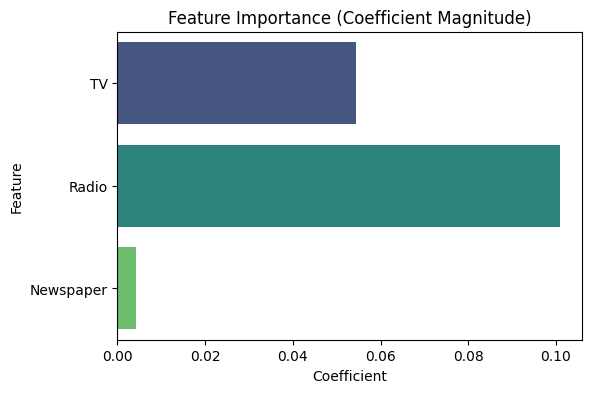

In [47]:
plt.figure(figsize=(6,4))
sns.barplot(x="Coefficient", y="Feature", data=coefficients, palette="viridis")
plt.title("Feature Importance (Coefficient Magnitude)")
plt.show()

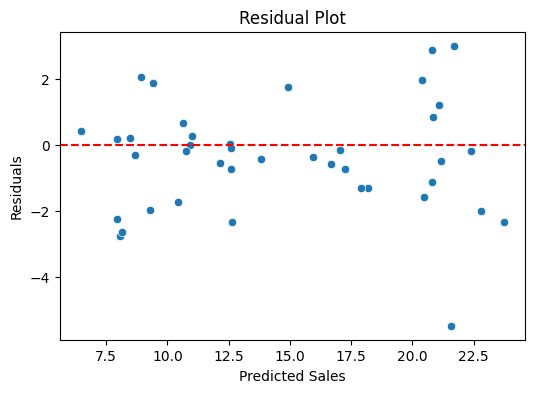

In [48]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

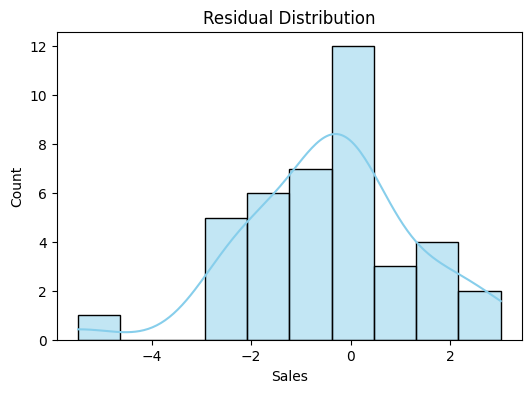

In [49]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, bins=10, color="skyblue")
plt.title("Residual Distribution")
plt.show()

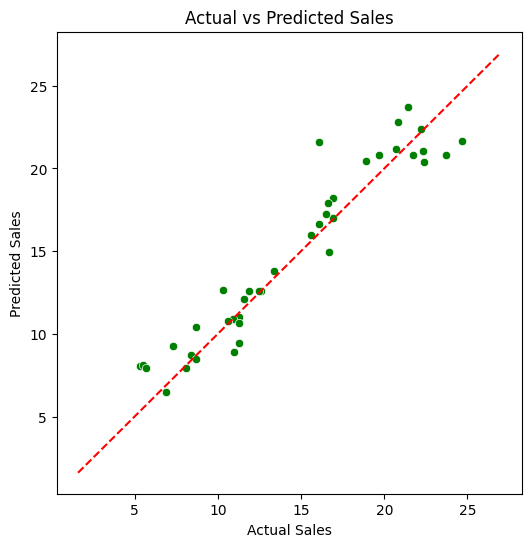

In [50]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, color="green")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 45-degree line
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()
